In [1]:
# ============================================================
# CELL 1: Install & Import Libraries
# ============================================================
!pip install kagglehub umap-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import json
import pickle
from pathlib import Path

import tensorflow as tf
from tensorflow import keras

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors

sns.set_style("whitegrid")
print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")
print("All libraries loaded successfully!")


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
All libraries loaded successfully!


In [2]:
# ============================================================
# CELL 2: Mount Drive and Load Stratified VAE Models
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

output_dir  = '/content/drive/MyDrive/DeepSentinel/DeepSentinel_Output_v2'
results_dir = '/content/drive/MyDrive/DeepSentinel/DeepSentinel_Results_v2'
model_dir   = f'{results_dir}/models'
dsaa_dir    = '/content/drive/MyDrive/DeepSentinel/DeepSentinel_DSAA_v2'
os.makedirs(dsaa_dir, exist_ok=True)

feature_cols = ['F1_log_amount', 'F2_amount_balance_ratio', 'F3_balance_consistency',
                'F4_balance_change_ratio', 'F5_dest_balance_ratio', 'F6_hour',
                'F7_day', 'F8_is_large',
                'F9_dest_starts_empty', 'F10_recipient_emptied',
                'F11_account_velocity', 'F12_round_amount', 'F13_zero_dest_history']
N_FEAT = len(feature_cols)  # 13

# Latent dim per VAE (TRANSFER=8, CASH_OUT=16) — Signal 2 is zero-padded to MAX_LATENT
LATENT_TRANSFER = 8
LATENT_CASHOUT  = 16
MAX_LATENT      = max(LATENT_TRANSFER, LATENT_CASHOUT)  # 16

print("Loading stratified VAEs and scalers...")

# The saved encoders contain a Lambda layer with a closure-scoped `sampling`
# function that Keras cannot deserialise across runtimes. To avoid this issue
# entirely, we REBUILD each encoder/decoder architecture and load only the
# weights. This is more robust than `custom_objects` and works on any Keras version.
from tensorflow.keras import layers as L
from tensorflow.keras import Model

INPUT_DIM = N_FEAT  # 13

def build_encoder_for_dsaa(name, hidden_1, hidden_2, latent_dim):
    """Rebuild encoder architecture (without Lambda sampling — we use z_mean directly).
       Returns a Model that outputs (z_mean, z_log_var)."""
    inp = keras.Input(shape=(INPUT_DIM,), name=f'{name}_enc_input')
    x = L.Dense(hidden_1, activation='relu', name=f'{name}_enc_h1')(inp)
    x = L.Dense(hidden_2, activation='relu', name=f'{name}_enc_h2')(x)
    z_mean    = L.Dense(latent_dim, name=f'{name}_z_mean')(x)
    z_log_var = L.Dense(latent_dim, name=f'{name}_z_log_var')(x)
    return Model(inp, [z_mean, z_log_var], name=f'{name}_encoder')

def build_decoder_for_dsaa(name, hidden_1, hidden_2, latent_dim):
    inp = keras.Input(shape=(latent_dim,), name=f'{name}_dec_input')
    x = L.Dense(hidden_2, activation='relu', name=f'{name}_dec_h1')(inp)
    x = L.Dense(hidden_1, activation='relu', name=f'{name}_dec_h2')(x)
    out = L.Dense(INPUT_DIM, activation='sigmoid', name=f'{name}_dec_out')(x)
    return Model(inp, out, name=f'{name}_decoder')

# Architecture per type — must match the one used during training (Stratified VAE)
ARCH = {
    'transfer': {'hidden_1': 32, 'hidden_2': 16, 'latent_dim': LATENT_TRANSFER},
    'cashout':  {'hidden_1': 64, 'hidden_2': 32, 'latent_dim': LATENT_CASHOUT},
    'payment':  {'hidden_1': 32, 'hidden_2': 16, 'latent_dim': LATENT_TRANSFER},
}

# Build empty models, then load weights from the saved .keras files
enc_t = build_encoder_for_dsaa('vae_transfer', **ARCH['transfer'])
dec_t = build_decoder_for_dsaa('vae_transfer', **ARCH['transfer'])
enc_c = build_encoder_for_dsaa('vae_cashout',  **ARCH['cashout'])
dec_c = build_decoder_for_dsaa('vae_cashout',  **ARCH['cashout'])
enc_p = build_encoder_for_dsaa('vae_payment',  **ARCH['payment'])
dec_p = build_decoder_for_dsaa('vae_payment',  **ARCH['payment'])

# Load weights (skip_mismatch=True ignores the missing Lambda layer in the rebuild)
enc_t.load_weights(f'{model_dir}/vae_transfer_encoder.keras', skip_mismatch=True)
dec_t.load_weights(f'{model_dir}/vae_transfer_decoder.keras', skip_mismatch=True)
enc_c.load_weights(f'{model_dir}/vae_cashout_encoder.keras',  skip_mismatch=True)
dec_c.load_weights(f'{model_dir}/vae_cashout_decoder.keras',  skip_mismatch=True)
enc_p.load_weights(f'{model_dir}/vae_payment_encoder.keras',  skip_mismatch=True)
dec_p.load_weights(f'{model_dir}/vae_payment_decoder.keras',  skip_mismatch=True)

print("  Architectures rebuilt and weights loaded.")

# Scalers
with open(f'{model_dir}/scaler_transfer.pkl', 'rb') as f: scaler_t = pickle.load(f)
with open(f'{model_dir}/scaler_cashout.pkl',  'rb') as f: scaler_c = pickle.load(f)
with open(f'{model_dir}/scaler_payment.pkl',  'rb') as f: scaler_p = pickle.load(f)

# Per-type thresholds + normalization stats
with open(f'{model_dir}/stratified_config.json') as f:
    strat_cfg = json.load(f)

print("Models, scalers, and thresholds loaded.")

# Load fraud transactions for typology discovery
transfer_all = pd.read_csv(f'{output_dir}/TRANSFER_all_features.csv')
cashout_all  = pd.read_csv(f'{output_dir}/CASH_OUT_all_features.csv')

transfer_fraud = transfer_all[transfer_all['isFraud'] == 1].copy()
cashout_fraud  = cashout_all[cashout_all['isFraud'] == 1].copy()

print(f"\nFraud transactions to analyse:")
print(f"  TRANSFER fraud: {len(transfer_fraud):,}")
print(f"  CASH_OUT fraud: {len(cashout_fraud):,}")
print(f"  Total fraud:    {len(transfer_fraud) + len(cashout_fraud):,}")


Mounted at /content/drive
Loading stratified VAEs and scalers...
  Architectures rebuilt and weights loaded.
Models, scalers, and thresholds loaded.

Fraud transactions to analyse:
  TRANSFER fraud: 4,097
  CASH_OUT fraud: 4,116
  Total fraud:    8,213


In [3]:
# ============================================================
# CELL 3: Compute Signal 1 (Per-Feature Reconstruction %)
# ============================================================
print("=" * 60)
print("COMPUTING SIGNAL 1 — PER-FEATURE RECONSTRUCTION %")
print("=" * 60)
print("For each fraud transaction, compute the % contribution of each")
print("feature (F1-F8) to the total reconstruction error.")
print("Each row sums to 1.0 — interpretable as feature attribution.")

def compute_signal_1(X_scaled, encoder, decoder):
    """
    Compute per-feature reconstruction error percentage.
    Returns array of shape (n_samples, N_FEAT=13) where each row sums to 1.0.

    The rebuilt encoder returns (z_mean, z_log_var). At inference we use z_mean
    directly as the latent code (no stochastic sampling), which is standard
    practice for VAE inference.
    """
    z_mean, z_log_var = encoder.predict(X_scaled, batch_size=1024, verbose=0)
    X_recon = decoder.predict(z_mean, batch_size=1024, verbose=0)

    # Per-feature squared error
    err_per_feat = (X_scaled - X_recon) ** 2  # shape (n, N_FEAT)

    # Normalize each row to sum to 1.0
    total = err_per_feat.sum(axis=1, keepdims=True) + 1e-8
    signal_1 = err_per_feat / total

    return signal_1, z_mean, z_log_var, X_recon


# TRANSFER fraud
X_t_fraud = scaler_t.transform(transfer_fraud[feature_cols].values)
sig1_t, zm_t, zlv_t, xr_t = compute_signal_1(X_t_fraud, enc_t, dec_t)

# CASH_OUT fraud
X_c_fraud = scaler_c.transform(cashout_fraud[feature_cols].values)
sig1_c, zm_c, zlv_c, xr_c = compute_signal_1(X_c_fraud, enc_c, dec_c)

# Combine
sig1_all = np.vstack([sig1_t, sig1_c])

# Verify each row sums to 1.0
print(f"\nSignal 1 shape: {sig1_all.shape} (rows sum to 1.0)")
print(f"Row sum check: min={sig1_all.sum(axis=1).min():.4f}, "
      f"max={sig1_all.sum(axis=1).max():.4f}")

# Mean Signal 1 across all fraud (which features dominate on average?)
mean_sig1 = sig1_all.mean(axis=0)
print(f"\nMean Signal 1 across all fraud transactions:")
for i, (col, val) in enumerate(zip(feature_cols, mean_sig1)):
    bar = '█' * int(val * 50)
    print(f"  {col:<30} {val:.4f}  {bar}")


COMPUTING SIGNAL 1 — PER-FEATURE RECONSTRUCTION %
For each fraud transaction, compute the % contribution of each
feature (F1-F8) to the total reconstruction error.
Each row sums to 1.0 — interpretable as feature attribution.



Signal 1 shape: (8213, 13) (rows sum to 1.0)
Row sum check: min=0.9998, max=1.0000

Mean Signal 1 across all fraud transactions:
  F1_log_amount                  0.0519  ██
  F2_amount_balance_ratio        0.0011  
  F3_balance_consistency         0.1127  █████
  F4_balance_change_ratio        0.0426  ██
  F5_dest_balance_ratio          0.0061  
  F6_hour                        0.0522  ██
  F7_day                         0.1211  ██████
  F8_is_large                    0.2351  ███████████
  F9_dest_starts_empty           0.0047  
  F10_recipient_emptied          0.1940  █████████
  F11_account_velocity           0.0013  
  F12_round_amount               0.0140  
  F13_zero_dest_history          0.1632  ████████


In [4]:
# ============================================================
# CELL 4: Compute Signal 2 (Per-Latent-Dim KL %)
# ============================================================
print("=" * 60)
print("COMPUTING SIGNAL 2 — PER-LATENT-DIM KL %")
print("=" * 60)
print("For each fraud transaction, compute the % contribution of each")
print("latent dimension (dim_0 - dim_7) to the total KL divergence.")
print("Reveals WHICH learned behavioural pattern was violated.")

def compute_signal_2(z_mean, z_log_var, target_dim=MAX_LATENT):
    """
    Compute per-latent-dimension KL divergence percentage.
    Zero-pads to `target_dim` so different VAE latent sizes can be combined.
    Returns array of shape (n_samples, target_dim) where each row sums to 1.0
    (rows from a smaller-latent VAE will have zero contribution in the padded tail).
    """
    # KL per dimension: 0.5 * (mu^2 + sigma^2 - 1 - log(sigma^2))
    kl_per_dim = -0.5 * (1 + z_log_var - z_mean**2 - np.exp(z_log_var))
    # Floor at 0 (KL is theoretically non-negative; numerical noise can produce tiny negatives)
    kl_per_dim = np.maximum(kl_per_dim, 0.0)

    total = kl_per_dim.sum(axis=1, keepdims=True) + 1e-8
    signal_2 = kl_per_dim / total

    # Zero-pad to target_dim (right-pad with zeros so smaller-latent VAEs match)
    actual_dim = signal_2.shape[1]
    if actual_dim < target_dim:
        pad = np.zeros((signal_2.shape[0], target_dim - actual_dim), dtype=signal_2.dtype)
        signal_2 = np.hstack([signal_2, pad])
    return signal_2


# TRANSFER has 8 latent dims, CASH_OUT has 16 — both pad up to MAX_LATENT (16)
sig2_t = compute_signal_2(zm_t, zlv_t)
sig2_c = compute_signal_2(zm_c, zlv_c)
sig2_all = np.vstack([sig2_t, sig2_c])  # shape (n, MAX_LATENT)

# Verify
print(f"\nSignal 2 shape: {sig2_all.shape} (rows sum to 1.0)")
print(f"Row sum check: min={sig2_all.sum(axis=1).min():.4f}, "
      f"max={sig2_all.sum(axis=1).max():.4f}")

mean_sig2 = sig2_all.mean(axis=0)
print(f"\nMean Signal 2 across all fraud transactions ({MAX_LATENT} dims, padded):")
for i, val in enumerate(mean_sig2):
    bar = '█' * int(val * 50)
    print(f"  dim_{i:<2}                          {val:.4f}  {bar}")

# Health check: if all Signal 2 values are uniform (~0.125), KL has collapsed
sig2_uniformity = mean_sig2.std()
print(f"\nSignal 2 std across dims: {sig2_uniformity:.4f}")
if sig2_uniformity < 0.02:
    print("  ⚠️  Signal 2 is nearly uniform — KL collapse detected.")
    print("     DSAA Signal 2 will provide weak attribution.")
    print("     Consider further lowering Free Bits in 04_Stratified_VAE.")
else:
    print("  ✅ Signal 2 has meaningful variation across dimensions.")


COMPUTING SIGNAL 2 — PER-LATENT-DIM KL %
For each fraud transaction, compute the % contribution of each
latent dimension (dim_0 - dim_7) to the total KL divergence.
Reveals WHICH learned behavioural pattern was violated.

Signal 2 shape: (8213, 16) (rows sum to 1.0)
Row sum check: min=1.0000, max=1.0000

Mean Signal 2 across all fraud transactions (16 dims, padded):
  dim_0                           0.0513  ██
  dim_1                           0.0619  ███
  dim_2                           0.0598  ██
  dim_3                           0.1086  █████
  dim_4                           0.1464  ███████
  dim_5                           0.1019  █████
  dim_6                           0.0583  ██
  dim_7                           0.1351  ██████
  dim_8                           0.0226  █
  dim_9                           0.0591  ██
  dim_10                          0.0749  ███
  dim_11                          0.0243  █
  dim_12                          0.0229  █
  dim_13                        

In [5]:
# ============================================================
# CELL 5: Build Anomaly Fingerprints (29-dim)
# ============================================================
print("=" * 60)
print("BUILDING 16-DIM ANOMALY FINGERPRINTS")
print("=" * 60)

# Concatenate Signal 1 (8) + Signal 2 (8) = 16 dimensions per fraud transaction
fingerprints = np.hstack([sig1_all, sig2_all])

# Track which type each fraud belongs to
fraud_type_labels = (['TRANSFER'] * len(sig1_t)) + (['CASH_OUT'] * len(sig1_c))
fraud_type_arr = np.array(fraud_type_labels)

# Build labels for the fingerprint dimensions
dim_labels = ['S1_' + c.replace('_', '') for c in feature_cols] + \
             [f'S2_dim{i}' for i in range(MAX_LATENT)]

print(f"Fingerprint shape: {fingerprints.shape}")
print(f"  Signal 1 ({N_FEAT} dims): F1-F{N_FEAT} reconstruction %")
print(f"  Signal 2 ({MAX_LATENT} dims): dim_0 - dim_{MAX_LATENT-1} KL % (padded)")
print(f"  Total: {N_FEAT + MAX_LATENT} dims per fraud transaction")


BUILDING 16-DIM ANOMALY FINGERPRINTS
Fingerprint shape: (8213, 29)
  Signal 1 (13 dims): F1-F13 reconstruction %
  Signal 2 (16 dims): dim_0 - dim_15 KL % (padded)
  Total: 29 dims per fraud transaction


DBSCAN PARAMETER SEARCH (k-distance plot for eps)


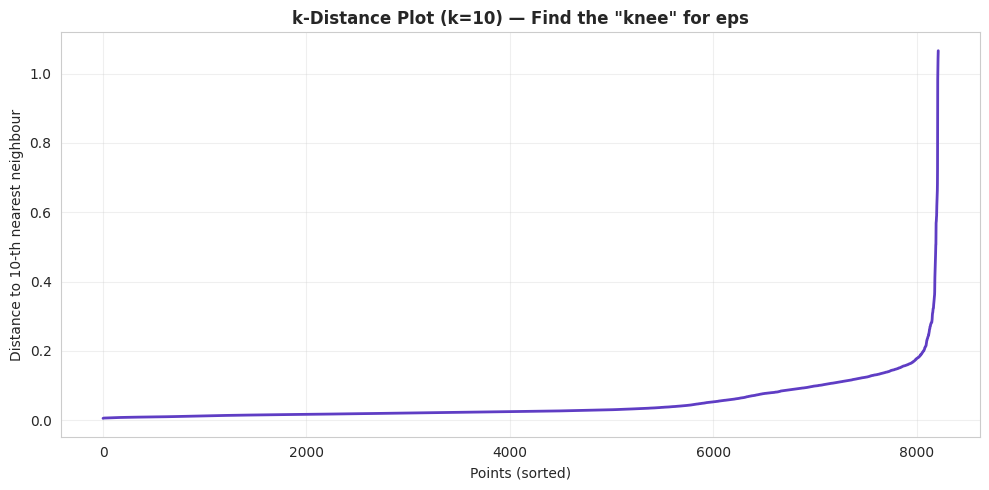


Suggested eps (90th percentile of k-distances): 0.1178
min_samples = 10 (rule of thumb: 2 * dimensionality)


In [6]:
# ============================================================
# CELL 6: DBSCAN Parameter Search (k-distance plot)
# ============================================================
print("=" * 60)
print("DBSCAN PARAMETER SEARCH (k-distance plot for eps)")
print("=" * 60)

# Use k-distance plot to find good eps
# For a min_samples value of k, plot the distance to the k-th nearest neighbour
# The "knee" of this plot suggests a good eps
k = 10
neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(fingerprints)
dists, _ = neighbors.kneighbors(fingerprints)

# Sort the k-th nearest neighbour distance
k_dists = np.sort(dists[:, -1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_dists, color='#5f3dc4', linewidth=2)
ax.set_xlabel('Points (sorted)')
ax.set_ylabel(f'Distance to {k}-th nearest neighbour')
ax.set_title(f'k-Distance Plot (k={k}) — Find the "knee" for eps', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{dsaa_dir}/dbscan_kdistance.png', dpi=150, bbox_inches='tight')
plt.show()

# Heuristic: the elbow is approximately at the median distance
suggested_eps = float(np.percentile(k_dists, 90))
print(f"\nSuggested eps (90th percentile of k-distances): {suggested_eps:.4f}")
print(f"min_samples = {k} (rule of thumb: 2 * dimensionality)")


In [7]:
# ============================================================
# CELL 7: Run DBSCAN Clustering
# ============================================================
print("=" * 60)
print("RUNNING DBSCAN ON 16-DIM ANOMALY FINGERPRINTS")
print("=" * 60)

EPS = suggested_eps  # tune this manually if needed
MIN_SAMPLES = 10

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, metric='euclidean', n_jobs=-1)
cluster_labels = dbscan.fit_predict(fingerprints)

# Cluster summary
unique_clusters = sorted(set(cluster_labels))
n_clusters = len([c for c in unique_clusters if c != -1])
n_noise = (cluster_labels == -1).sum()

print(f"\nDBSCAN results:")
print(f"  eps={EPS:.4f}, min_samples={MIN_SAMPLES}")
print(f"  Clusters discovered: {n_clusters}")
print(f"  Noise points:        {n_noise} ({n_noise/len(cluster_labels)*100:.1f}%)")

# Cluster sizes
print(f"\nCluster sizes:")
for cid in unique_clusters:
    count = (cluster_labels == cid).sum()
    label = 'noise' if cid == -1 else f'cluster {cid}'
    print(f"  {label:<12} {count:>6} ({count/len(cluster_labels)*100:.1f}%)")

# Silhouette score (only on non-noise points)
non_noise_mask = cluster_labels != -1
if n_clusters >= 2 and non_noise_mask.sum() > 1:
    sil_score = silhouette_score(fingerprints[non_noise_mask], cluster_labels[non_noise_mask])
    print(f"\nSilhouette score (non-noise): {sil_score:.4f}")
    if sil_score > 0.5:
        print("  ✅ Strong cluster separation.")
    elif sil_score > 0.25:
        print("  🟡 Moderate cluster separation.")
    else:
        print("  ⚠️  Weak separation — consider tuning eps or using cosine metric.")
else:
    sil_score = None
    print("Silhouette undefined (need ≥ 2 clusters)")


RUNNING DBSCAN ON 16-DIM ANOMALY FINGERPRINTS

DBSCAN results:
  eps=0.1178, min_samples=10
  Clusters discovered: 19
  Noise points:        457 (5.6%)

Cluster sizes:
  noise           457 (5.6%)
  cluster 0      3386 (41.2%)
  cluster 1       511 (6.2%)
  cluster 2       141 (1.7%)
  cluster 3        14 (0.2%)
  cluster 4      1143 (13.9%)
  cluster 5      1719 (20.9%)
  cluster 6       172 (2.1%)
  cluster 7       177 (2.2%)
  cluster 8        48 (0.6%)
  cluster 9        53 (0.6%)
  cluster 10       64 (0.8%)
  cluster 11       65 (0.8%)
  cluster 12       29 (0.4%)
  cluster 13       18 (0.2%)
  cluster 14       87 (1.1%)
  cluster 15       37 (0.5%)
  cluster 16       10 (0.1%)
  cluster 17       73 (0.9%)
  cluster 18        9 (0.1%)

Silhouette score (non-noise): 0.3587
  🟡 Moderate cluster separation.


In [8]:
# ============================================================
# CELL 8: Identify Dominant Features per Cluster + Map to Typology
# ============================================================
print("=" * 60)
print("CLUSTER ANALYSIS — DOMINANT FEATURES & TYPOLOGY MAPPING")
print("=" * 60)

def map_to_typology(cluster_centroid, top_dims):
    """
    Heuristic: map cluster centroid pattern to a FATF-aligned typology label.
    top_dims is a list of (dim_label, value) tuples sorted by value descending.
    """
    top_dim_names = [d[0] for d in top_dims[:3]]
    top_str = ' '.join(top_dim_names)

    # Rule-based typology assignment using which features dominate
    # F9-F13 mule-network features take priority since they target CASH_OUT fraud
    if 'S1_F9deststartsempty' in top_dim_names or 'S1_F13zerodesthistory' in top_dim_names:
        return ('MULE_NETWORK_FRESH',
                'Fresh mule account pattern. F9 (dest starts empty) and/or F13 (zero dest history) '
                'dominant — destination account has no prior balance activity. '
                'Maps to FATF Layering via fresh mule accounts.')
    if 'S1_F10recipientemptied' in top_dim_names:
        return ('PASS_THROUGH_MULE',
                'Pass-through mule pattern. F10 (recipient emptied) dominant — funds in then immediately '
                'out. Maps to FATF Layering via active mules.')
    if 'S1_F12roundamount' in top_dim_names:
        return ('ROUND_AMOUNT_FRAUD',
                'Round-number amount fraud. F12 dominant — fraudster used a clean round figure '
                '(10K, 50K, 100K). Maps to FATF Structuring / Placement.')
    if 'S1_F2amountbalanceratio' in top_dim_names and 'S1_F3balanceconsistency' in top_dim_names:
        return ('ACCOUNT_DRAINING',
                'Full or near-full balance extraction. F2 (amount-to-balance ratio) and F3 '
                '(balance consistency) drive the reconstruction anomaly. Maps to FATF Layering / Cash-Out.')
    if 'S1_F4balancechangeratio' in top_dim_names and ('S1_F6hour' in top_dim_names or 'S1_F8islarge' in top_dim_names):
        return ('SMURFING_ESCALATION',
                'Escalating partial transfers. F4 (balance change ratio) dominant with temporal/size '
                'co-deviation. Maps to FATF Structuring / Smurfing.')
    if 'S1_F5destbalanceratio' in top_dim_names:
        return ('MULE_NETWORK_BALANCE',
                'Funds rapidly moved through destination accounts. F5 (destination balance ratio) '
                'dominant. Maps to FATF Layering via Mules.')
    if 'S1_F8islarge' in top_dim_names and 'S1_F1logamount' in top_dim_names:
        return ('LARGE_TRANSFER_ANOMALY',
                'Outlier transaction amount. F1 (log amount) and F8 (P95 outlier) dominant. '
                'Maps to FATF Placement of large illicit funds.')
    if any(d.startswith('S2_') for d in top_dim_names[:2]):
        return ('LATENT_PATTERN_VIOLATION',
                f'Behavioural pattern violation in latent space ({top_str}). '
                'Atypical combination of feature values not seen in normal behaviour.')
    return ('MIXED_ANOMALY',
            f'Mixed-feature anomaly. Top contributors: {top_str}.')


typology_records = []
print(f"\n{'Cluster':<10} {'Size':<8} {'Type':<28} {'Top Components':<40}")
print("-" * 95)

for cid in unique_clusters:
    if cid == -1:
        continue  # skip noise

    cluster_mask = cluster_labels == cid
    cluster_size = cluster_mask.sum()
    cluster_centroid = fingerprints[cluster_mask].mean(axis=0)

    # Top 3 dimensions in centroid
    sorted_idx = np.argsort(cluster_centroid)[::-1]
    top_dims = [(dim_labels[i], float(cluster_centroid[i])) for i in sorted_idx[:5]]

    # Map to typology
    typology_label, typology_desc = map_to_typology(cluster_centroid, top_dims)

    # Type purity (TRANSFER vs CASH_OUT)
    types_in_cluster = fraud_type_arr[cluster_mask]
    transfer_pct = (types_in_cluster == 'TRANSFER').sum() / cluster_size * 100
    cashout_pct  = (types_in_cluster == 'CASH_OUT').sum() / cluster_size * 100

    typology_records.append({
        'cluster_id':       int(cid),
        'cluster_size':     int(cluster_size),
        'typology_label':   typology_label,
        'typology_description': typology_desc,
        'top_dims':         top_dims,
        'transfer_pct':     float(transfer_pct),
        'cashout_pct':      float(cashout_pct),
        'centroid':         cluster_centroid.tolist()
    })

    top_str = ', '.join([f'{d[0]}={d[1]:.2f}' for d in top_dims[:3]])
    print(f"  {cid:<8} {cluster_size:<8} {typology_label:<28} {top_str}")

print(f"\nTypology assignments saved to typology_records.")


CLUSTER ANALYSIS — DOMINANT FEATURES & TYPOLOGY MAPPING

Cluster    Size     Type                         Top Components                          
-----------------------------------------------------------------------------------------------
  0        3386     MULE_NETWORK_FRESH           S1_F10recipientemptied=0.41, S1_F13zerodesthistory=0.35, S2_dim4=0.25
  1        511      PASS_THROUGH_MULE            S2_dim4=0.31, S1_F10recipientemptied=0.29, S1_F8islarge=0.28
  2        141      PASS_THROUGH_MULE            S2_dim4=0.38, S1_F10recipientemptied=0.23, S1_F12roundamount=0.23
  3        14       PASS_THROUGH_MULE            S1_F10recipientemptied=0.99, S2_dim10=0.15, S2_dim3=0.13
  4        1143     MIXED_ANOMALY                S1_F7day=0.51, S1_F4balancechangeratio=0.21, S2_dim10=0.17
  5        1719     LATENT_PATTERN_VIOLATION     S1_F8islarge=0.94, S2_dim10=0.17, S2_dim3=0.15
  6        172      LATENT_PATTERN_VIOLATION     S1_F7day=0.74, S2_dim9=0.19, S2_dim3=0.19
  7        1

In [9]:
# ============================================================
# CELL 9: t-SNE Visualization of Fingerprints
# ============================================================
print("=" * 60)
print("t-SNE 2D PROJECTION OF FINGERPRINTS")
print("=" * 60)

# Sample if too large (t-SNE is O(n^2))
sample_size = min(5000, len(fingerprints))
np.random.seed(42)
sample_idx = np.random.choice(len(fingerprints), size=sample_size, replace=False)
fp_sample = fingerprints[sample_idx]
labels_sample = cluster_labels[sample_idx]
type_sample = fraud_type_arr[sample_idx]

print(f"Running t-SNE on {sample_size} sampled fingerprints...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
fp_2d = tsne.fit_transform(fp_sample)
print("Done.")


t-SNE 2D PROJECTION OF FINGERPRINTS
Running t-SNE on 5000 sampled fingerprints...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Done.


GENERATING DSAA DASHBOARD


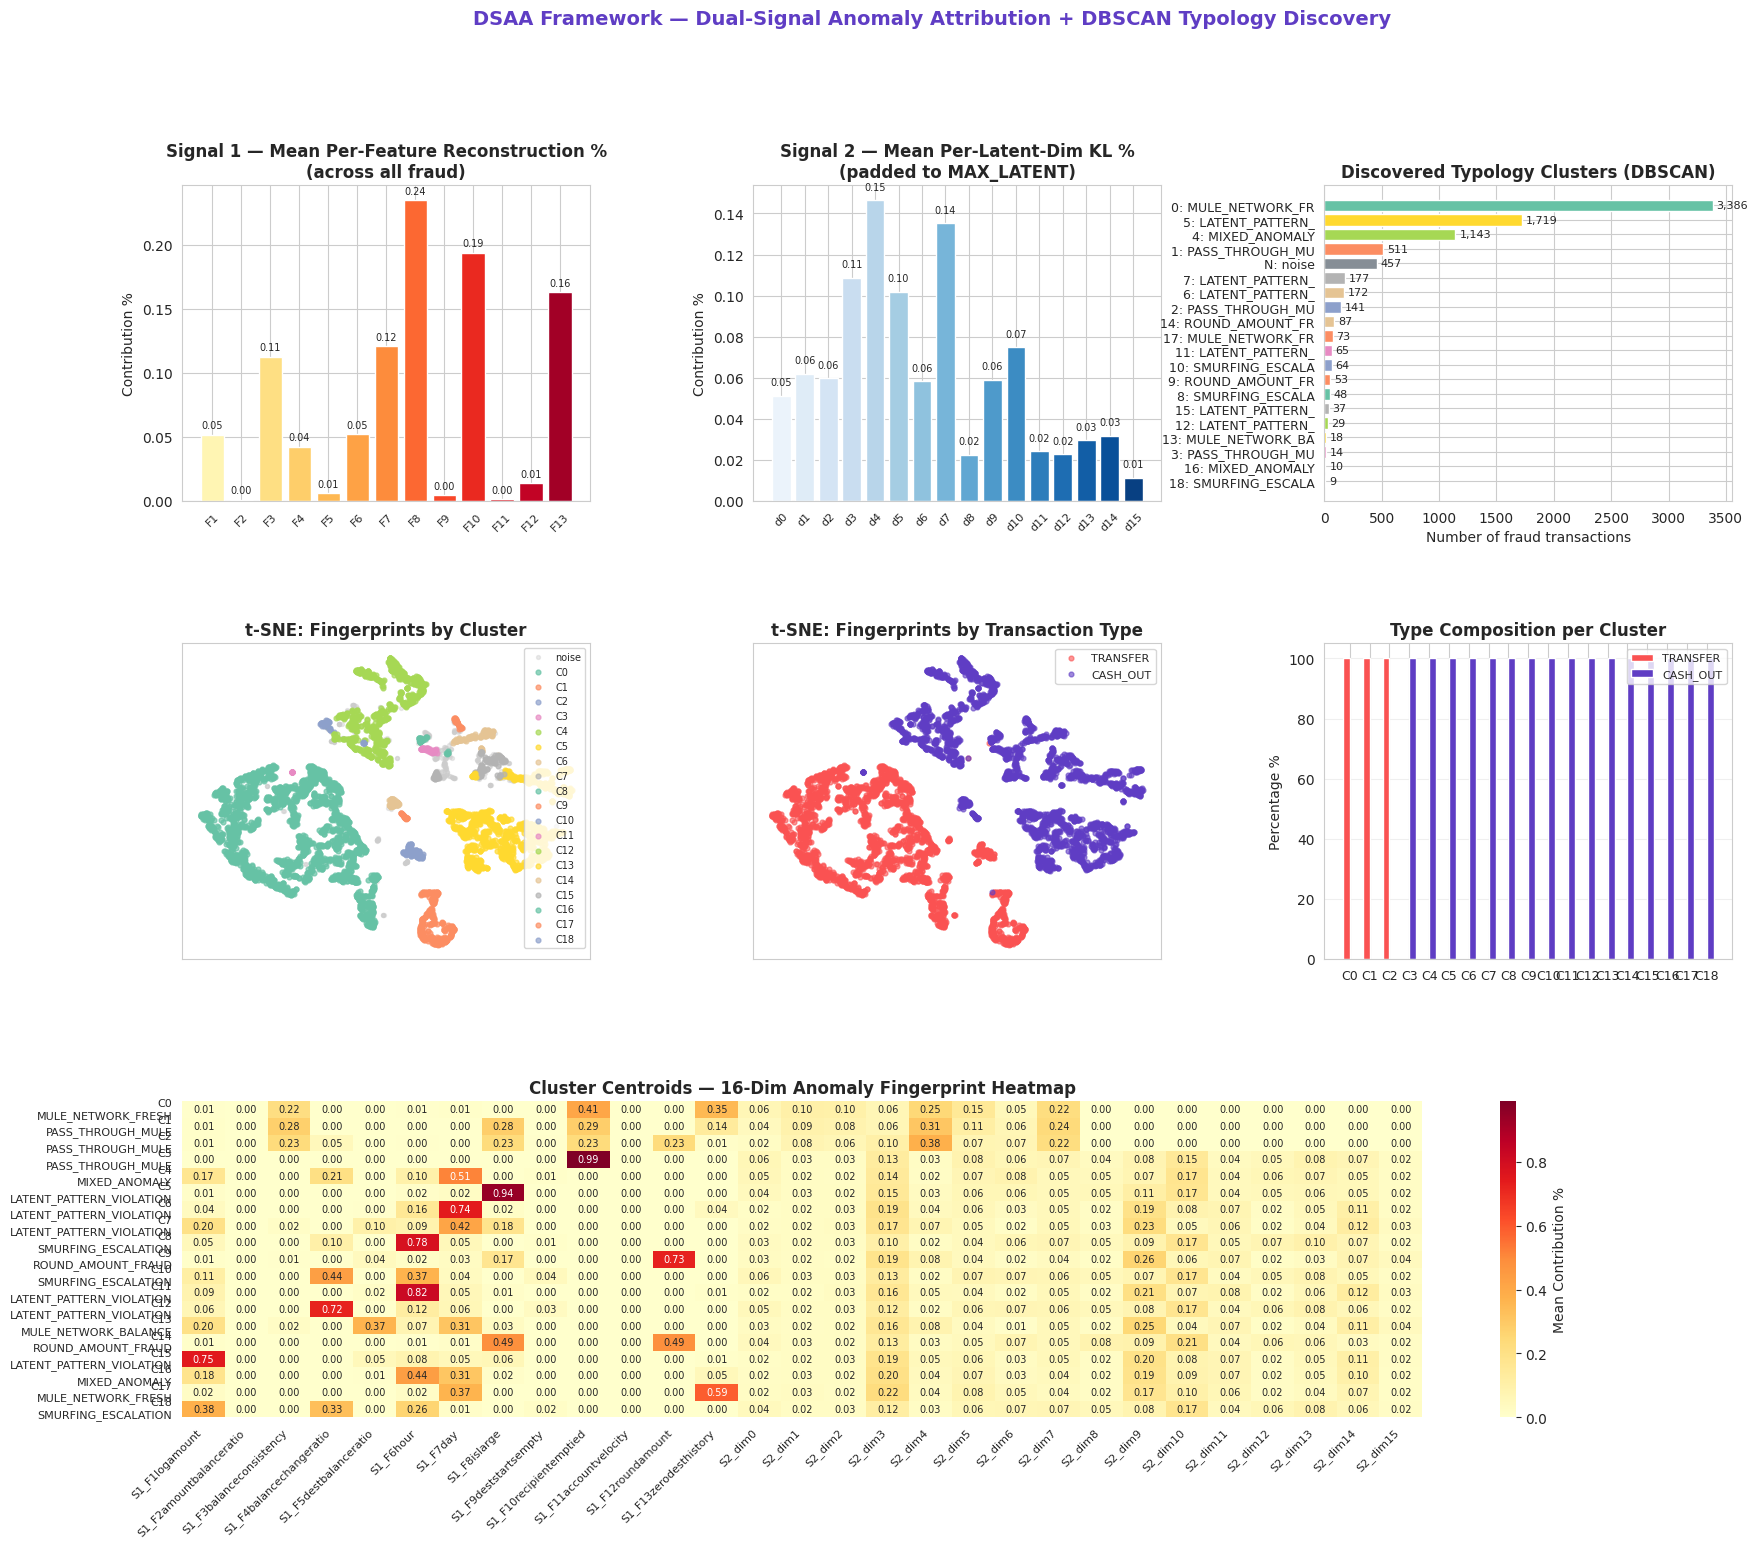

Saved: dsaa_dashboard.png


In [10]:
# ============================================================
# CELL 10: Comprehensive Visualization Dashboard
# ============================================================
print("=" * 60)
print("GENERATING DSAA DASHBOARD")
print("=" * 60)

fig = plt.figure(figsize=(20, 16))
fig.suptitle(
    'DSAA Framework — Dual-Signal Anomaly Attribution + DBSCAN Typology Discovery',
    fontsize=14, fontweight='bold', color='#5f3dc4', y=0.99
)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.4)

# --- Plot 1: Mean Signal 1 across all fraud ---
ax1 = fig.add_subplot(gs[0, 0])
colors_s1 = sns.color_palette("YlOrRd", N_FEAT)
ax1.bar(range(N_FEAT), mean_sig1, color=colors_s1)
ax1.set_xticks(range(N_FEAT))
ax1.set_xticklabels([f'F{i+1}' for i in range(N_FEAT)], fontsize=8, rotation=45)
ax1.set_title('Signal 1 — Mean Per-Feature Reconstruction %\n(across all fraud)', fontweight='bold')
ax1.set_ylabel('Contribution %')
for i, v in enumerate(mean_sig1):
    ax1.text(i, v + 0.005, f'{v:.2f}', ha='center', fontsize=7)

# --- Plot 2: Mean Signal 2 across all fraud ---
ax2 = fig.add_subplot(gs[0, 1])
colors_s2 = sns.color_palette("Blues", MAX_LATENT)
ax2.bar(range(MAX_LATENT), mean_sig2, color=colors_s2)
ax2.set_xticks(range(MAX_LATENT))
ax2.set_xticklabels([f'd{i}' for i in range(MAX_LATENT)], fontsize=8, rotation=45)
ax2.set_title('Signal 2 — Mean Per-Latent-Dim KL %\n(padded to MAX_LATENT)', fontweight='bold')
ax2.set_ylabel('Contribution %')
for i, v in enumerate(mean_sig2):
    ax2.text(i, v + 0.005, f'{v:.2f}', ha='center', fontsize=7)

# --- Plot 3: Cluster sizes ---
ax3 = fig.add_subplot(gs[0, 2])
cluster_size_data = [(rec['cluster_id'], rec['cluster_size'], rec['typology_label'])
                      for rec in typology_records]
cluster_size_data.append((-1, n_noise, 'noise'))
cluster_size_data.sort(key=lambda x: -x[1])
cids   = [str(c[0]) if c[0] != -1 else 'N' for c in cluster_size_data]
sizes  = [c[1] for c in cluster_size_data]
labels = [c[2][:15] for c in cluster_size_data]
bar_cols = ['#868e96' if c[0] == -1 else sns.color_palette("Set2", n_clusters)[c[0] % n_clusters]
            for c in cluster_size_data]
ax3.barh(range(len(sizes)), sizes, color=bar_cols)
ax3.set_yticks(range(len(sizes)))
ax3.set_yticklabels([f'{cid}: {lbl}' for cid, lbl in zip(cids, labels)], fontsize=9)
ax3.set_xlabel('Number of fraud transactions')
ax3.set_title('Discovered Typology Clusters (DBSCAN)', fontweight='bold')
ax3.invert_yaxis()
for i, sz in enumerate(sizes):
    ax3.text(sz + max(sizes)*0.01, i, f'{sz:,}', va='center', fontsize=8)

# --- Plot 4: t-SNE coloured by cluster ---
ax4 = fig.add_subplot(gs[1, 0])
palette = sns.color_palette("Set2", n_clusters) if n_clusters > 0 else ['#5f3dc4']
for cid in sorted(set(labels_sample)):
    mask = labels_sample == cid
    if cid == -1:
        ax4.scatter(fp_2d[mask, 0], fp_2d[mask, 1], c='#cccccc', s=8, alpha=0.4, label='noise')
    else:
        ax4.scatter(fp_2d[mask, 0], fp_2d[mask, 1],
                     c=[palette[cid % len(palette)]], s=12, alpha=0.7, label=f'C{cid}')
ax4.set_title('t-SNE: Fingerprints by Cluster', fontweight='bold')
ax4.legend(fontsize=7, loc='best')
ax4.set_xticks([]); ax4.set_yticks([])

# --- Plot 5: t-SNE coloured by transaction type ---
ax5 = fig.add_subplot(gs[1, 1])
for typ, col in [('TRANSFER', '#fa5252'), ('CASH_OUT', '#5f3dc4')]:
    mask = type_sample == typ
    ax5.scatter(fp_2d[mask, 0], fp_2d[mask, 1], c=col, s=12, alpha=0.6, label=typ)
ax5.set_title('t-SNE: Fingerprints by Transaction Type', fontweight='bold')
ax5.legend(fontsize=8, loc='best')
ax5.set_xticks([]); ax5.set_yticks([])

# --- Plot 6: Cluster type composition (TRANSFER vs CASH_OUT) ---
ax6 = fig.add_subplot(gs[1, 2])
cluster_ids   = [r['cluster_id'] for r in typology_records]
transfer_pcts = [r['transfer_pct'] for r in typology_records]
cashout_pcts  = [r['cashout_pct']  for r in typology_records]
x = np.arange(len(cluster_ids))
width = 0.35
ax6.bar(x - width/2, transfer_pcts, width, label='TRANSFER', color='#fa5252')
ax6.bar(x + width/2, cashout_pcts,  width, label='CASH_OUT', color='#5f3dc4')
ax6.set_xticks(x)
ax6.set_xticklabels([f'C{c}' for c in cluster_ids], fontsize=9)
ax6.set_title('Type Composition per Cluster', fontweight='bold')
ax6.set_ylabel('Percentage %')
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3, axis='y')

# --- Plot 7: Heatmap of cluster centroids (29 dims) ---
ax7 = fig.add_subplot(gs[2, :])
if len(typology_records) > 0:
    centroid_matrix = np.array([r['centroid'] for r in typology_records])
    cluster_names = [f"C{r['cluster_id']}\n{r['typology_label']}" for r in typology_records]
    sns.heatmap(centroid_matrix, annot=True, fmt='.2f', cmap='YlOrRd',
                xticklabels=dim_labels, yticklabels=cluster_names,
                ax=ax7, cbar_kws={'label': 'Mean Contribution %'},
                annot_kws={'size': 7})
    ax7.set_title('Cluster Centroids — 16-Dim Anomaly Fingerprint Heatmap',
                  fontweight='bold')
    ax7.set_xticklabels(ax7.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax7.set_yticklabels(ax7.get_yticklabels(), rotation=0, fontsize=8)

plt.savefig(f'{dsaa_dir}/dsaa_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: dsaa_dashboard.png")


RADAR CHARTS — TYPOLOGY FINGERPRINT SIGNATURES


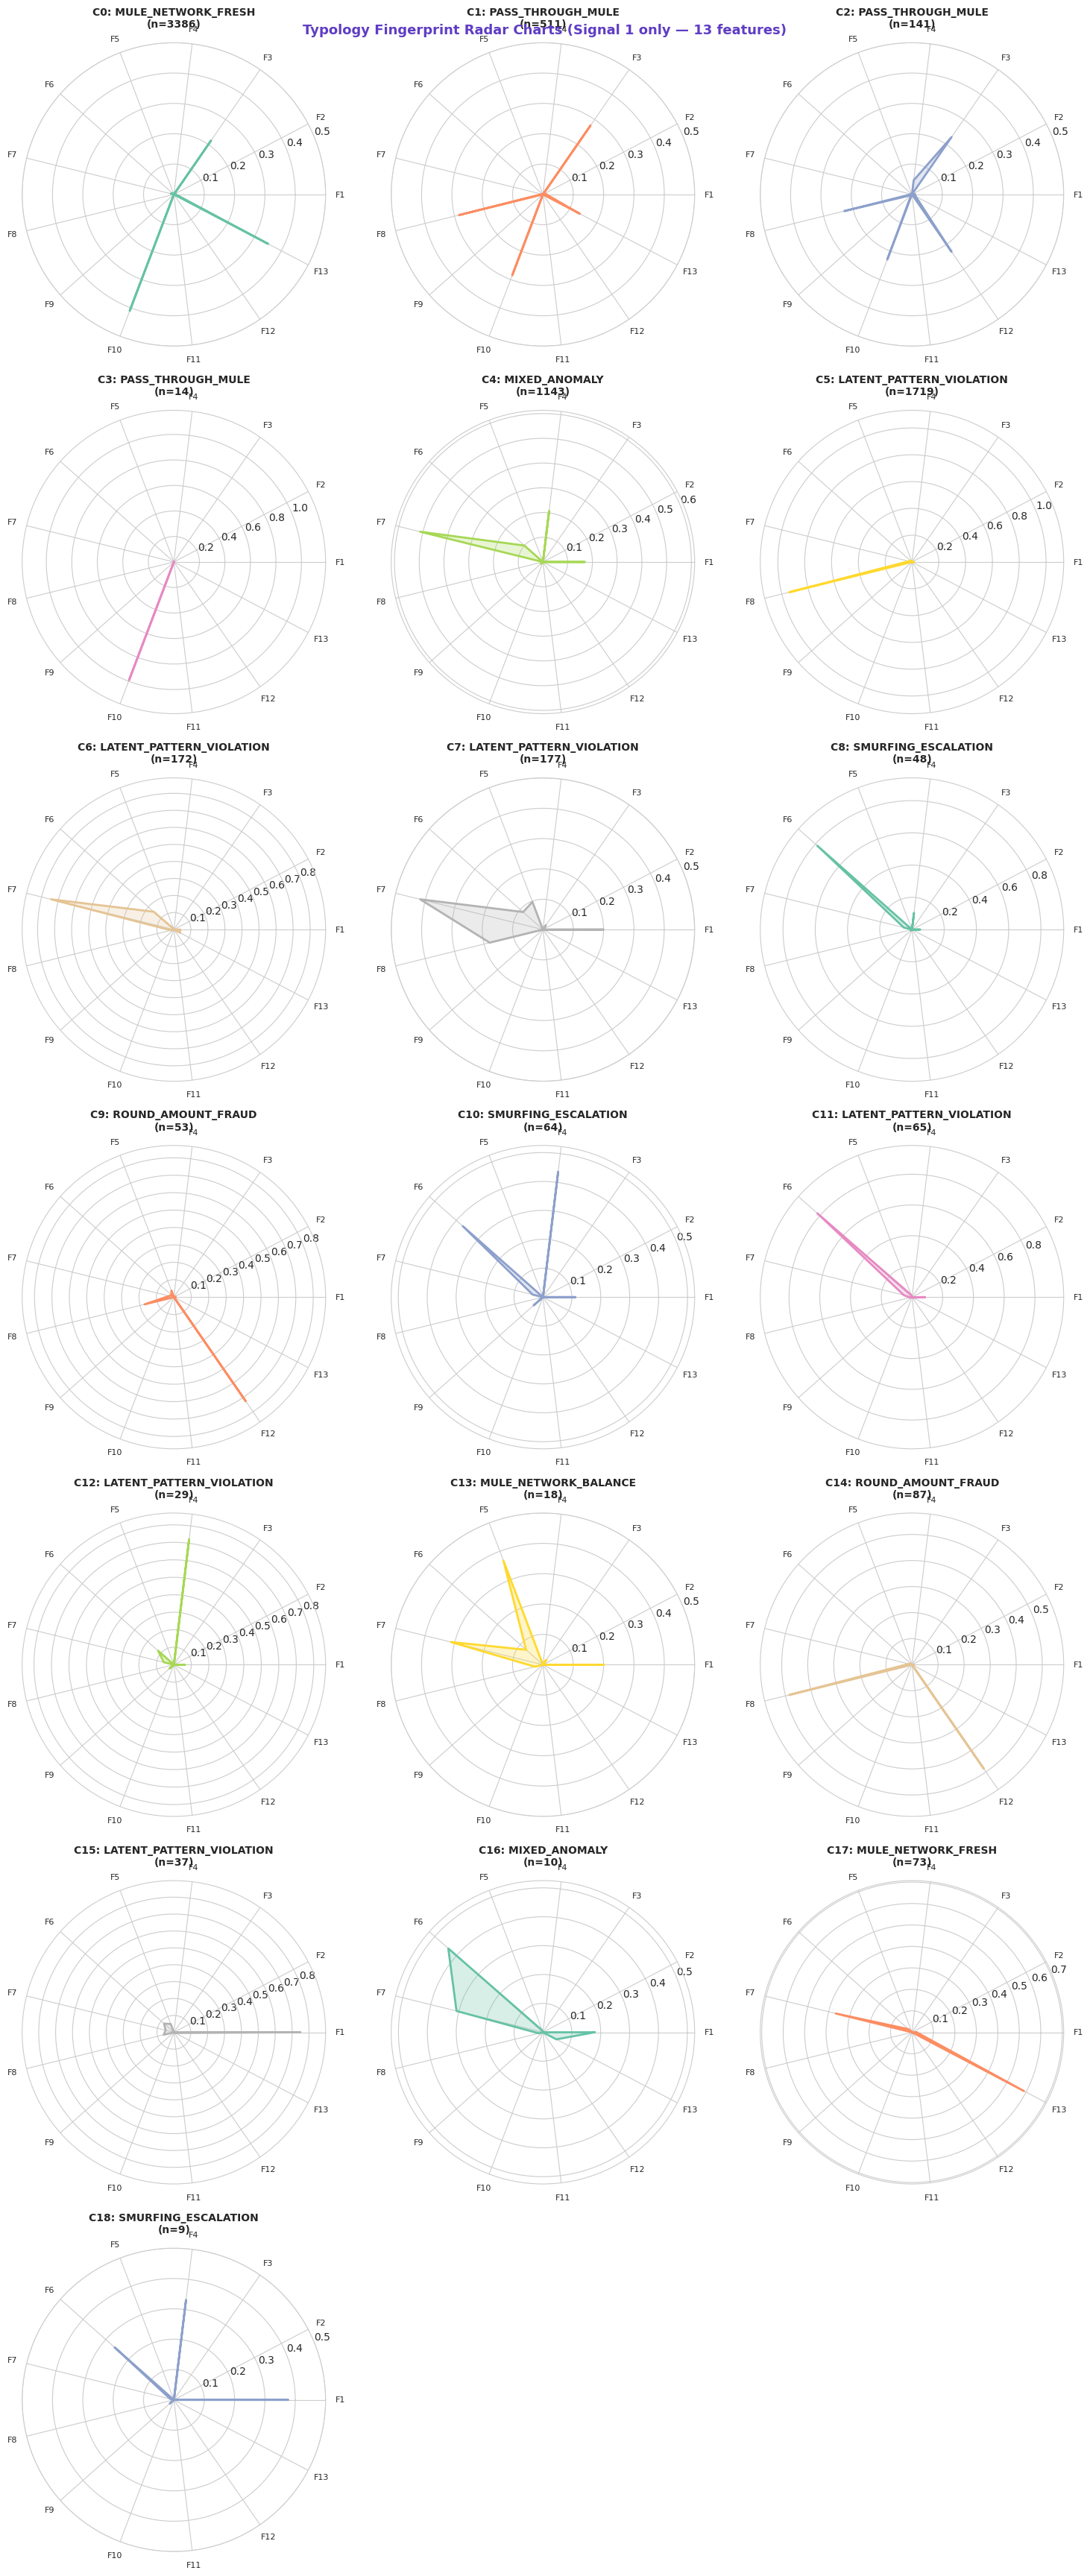

Saved: typology_radar.png


In [11]:
# ============================================================
# CELL 11: Radar Charts per Cluster (per-typology fingerprint signature)
# ============================================================
print("=" * 60)
print("RADAR CHARTS — TYPOLOGY FINGERPRINT SIGNATURES")
print("=" * 60)

if len(typology_records) > 0:
    n_recs = len(typology_records)
    n_cols = min(3, n_recs)
    n_rows = (n_recs + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows),
                              subplot_kw=dict(projection='polar'))
    fig.suptitle(f'Typology Fingerprint Radar Charts (Signal 1 only — {N_FEAT} features)',
                 fontsize=13, fontweight='bold', color='#5f3dc4')

    if n_recs == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()

    angles = np.linspace(0, 2*np.pi, N_FEAT, endpoint=False).tolist()
    angles += angles[:1]
    palette_radar = sns.color_palette("Set2", max(1, n_recs))

    for idx, rec in enumerate(typology_records):
        ax = axes[idx]
        sig1_centroid = rec['centroid'][:N_FEAT]
        values = sig1_centroid + sig1_centroid[:1]
        ax.plot(angles, values, color=palette_radar[idx % len(palette_radar)], linewidth=2)
        ax.fill(angles, values, color=palette_radar[idx % len(palette_radar)], alpha=0.25)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels([f'F{i+1}' for i in range(N_FEAT)], fontsize=8)
        ax.set_title(f"C{rec['cluster_id']}: {rec['typology_label']}\n(n={rec['cluster_size']})",
                     fontsize=10, fontweight='bold', pad=15)
        ax.set_ylim(0, max(0.5, max(sig1_centroid) * 1.2))

    # Hide unused subplots
    for idx in range(n_recs, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig(f'{dsaa_dir}/typology_radar.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: typology_radar.png")


In [12]:
# ============================================================
# CELL 12: Sample API Output Preview (one fraud transaction)
# ============================================================
print("=" * 60)
print("SAMPLE API OUTPUT PREVIEW")
print("=" * 60)
print("Showing the JSON that the FastAPI endpoint would return for one fraud transaction.")
print("(This validates that the DSAA fingerprint is ready for Member 4 integration.)")

# Pick a fraud sample for preview
sample_row = transfer_fraud.iloc[0]
sample_idx = 0
sample_sig1 = sig1_t[sample_idx]
sample_sig2 = sig2_t[sample_idx]
sample_cluster = cluster_labels[sample_idx]
sample_typology = next((r for r in typology_records if r['cluster_id'] == sample_cluster), None)

dom_feat_idx = int(np.argmax(sample_sig1))
dom_dim_idx  = int(np.argmax(sample_sig2))

api_preview = {
    "transaction_ref": {
        "nameOrig": "C_SAMPLE_TRANSFER",
        "step": 1,
        "composite_id": "C_SAMPLE_TRANSFER_1"
    },
    "behavioral_risk_score": 0.94,
    "risk_level": "CRITICAL",
    "detection_method": "Stratified-VAE-DSAA",
    "modality": "behavioral_anomaly",
    "transaction_type": "TRANSFER",
    "anomaly_fingerprint": {
        "signal_1_reconstruction_error": {
            **{c: round(float(sample_sig1[i]), 4) for i, c in enumerate(feature_cols)},
            "dominant_feature": feature_cols[dom_feat_idx],
            "dominant_feature_signal":
                f"{feature_cols[dom_feat_idx]} contributes {sample_sig1[dom_feat_idx]*100:.1f}% "
                f"of total reconstruction error — primary behavioral anomaly trigger."
        },
        "signal_2_kl_divergence": {
            **{f"dim_{i}": round(float(sample_sig2[i]), 4) for i in range(MAX_LATENT)},
            "dominant_dimension": f"dim_{dom_dim_idx}",
            "dominant_dimension_signal":
                f"Latent dim_{dom_dim_idx} contributes {sample_sig2[dom_dim_idx]*100:.1f}% "
                f"of total KL divergence — strongest violated behavioral pattern."
        }
    },
    "fraud_typology": {
        "cluster_id": int(sample_cluster) if sample_cluster != -1 else None,
        "typology_label": sample_typology['typology_label'] if sample_typology else 'NOISE_OUTLIER',
        "typology_description": sample_typology['typology_description'] if sample_typology
                                  else 'Outlier — no matching typology cluster.',
        "discovery_method": "DBSCAN"
    }
}

print("\nSample API output:")
print(json.dumps(api_preview, indent=2))



SAMPLE API OUTPUT PREVIEW
Showing the JSON that the FastAPI endpoint would return for one fraud transaction.
(This validates that the DSAA fingerprint is ready for Member 4 integration.)

Sample API output:
{
  "transaction_ref": {
    "nameOrig": "C_SAMPLE_TRANSFER",
    "step": 1,
    "composite_id": "C_SAMPLE_TRANSFER_1"
  },
  "behavioral_risk_score": 0.94,
  "risk_level": "CRITICAL",
  "detection_method": "Stratified-VAE-DSAA",
  "modality": "behavioral_anomaly",
  "transaction_type": "TRANSFER",
  "anomaly_fingerprint": {
    "signal_1_reconstruction_error": {
      "F1_log_amount": 0.0296,
      "F2_amount_balance_ratio": 0.0,
      "F3_balance_consistency": 0.0547,
      "F4_balance_change_ratio": 0.0,
      "F5_dest_balance_ratio": 0.0,
      "F6_hour": 0.0456,
      "F7_day": 0.0194,
      "F8_is_large": 0.0023,
      "F9_dest_starts_empty": 0.0,
      "F10_recipient_emptied": 0.4382,
      "F11_account_velocity": 0.0008,
      "F12_round_amount": 0.0,
      "F13_zero_dest_hi

In [13]:
# ============================================================
# CELL 13: Save All DSAA Artefacts
# ============================================================
print("=" * 60)
print("SAVING DSAA ARTEFACTS")
print("=" * 60)

# Save fingerprints (numpy)
np.savez(f'{dsaa_dir}/fingerprints.npz',
         fingerprints=fingerprints,
         signal_1=sig1_all,
         signal_2=sig2_all,
         cluster_labels=cluster_labels,
         fraud_type=fraud_type_arr)

# Save typology records (JSON)
with open(f'{dsaa_dir}/typology_records.json', 'w') as f:
    json.dump(typology_records, f, indent=2)

# Save DBSCAN config
with open(f'{dsaa_dir}/dbscan_config.json', 'w') as f:
    json.dump({
        'eps': float(EPS),
        'min_samples': int(MIN_SAMPLES),
        'metric': 'euclidean',
        'n_clusters_discovered': int(n_clusters),
        'n_noise_points': int(n_noise),
        'silhouette_score': float(sil_score) if sil_score is not None else None,
        'n_fraud_analysed': int(len(fingerprints))
    }, f, indent=2)

# Save mean signals (for thesis writing)
with open(f'{dsaa_dir}/mean_signals.json', 'w') as f:
    json.dump({
        'mean_signal_1': {feature_cols[i]: float(mean_sig1[i]) for i in range(N_FEAT)},
        'mean_signal_2': {f'dim_{i}': float(mean_sig2[i]) for i in range(MAX_LATENT)},
        'signal_2_uniformity_std': float(sig2_uniformity),
        'n_features': int(N_FEAT),
        'max_latent_dim': int(MAX_LATENT)
    }, f, indent=2)

print("Files saved:")
print("  fingerprints.npz       — 29-dim fingerprints + cluster labels")
print("  typology_records.json  — cluster → typology mapping")
print("  dbscan_config.json     — DBSCAN parameters and metrics")
print("  mean_signals.json      — mean Signal 1 / Signal 2 for thesis")
print("  dsaa_dashboard.png     — visualization dashboard")
print("  typology_radar.png     — per-typology radar charts")
print("  dbscan_kdistance.png   — k-distance plot for eps choice")


SAVING DSAA ARTEFACTS
Files saved:
  fingerprints.npz       — 29-dim fingerprints + cluster labels
  typology_records.json  — cluster → typology mapping
  dbscan_config.json     — DBSCAN parameters and metrics
  mean_signals.json      — mean Signal 1 / Signal 2 for thesis
  dsaa_dashboard.png     — visualization dashboard
  typology_radar.png     — per-typology radar charts
  dbscan_kdistance.png   — k-distance plot for eps choice


In [14]:
# ============================================================
# CELL 14: Verify Files on Google Drive
# ============================================================
print("Files saved to Google Drive:")
for f in sorted(os.listdir(dsaa_dir)):
    size = os.path.getsize(f'{dsaa_dir}/{f}') / 1024
    print(f"  {f}  ({size:.1f} KB)")


Files saved to Google Drive:
  dbscan_config.json  (0.2 KB)
  dbscan_kdistance.png  (47.6 KB)
  dsaa_dashboard.png  (832.3 KB)
  fingerprints.npz  (3530.3 KB)
  mean_signals.json  (1.3 KB)
  typology_radar.png  (1817.1 KB)
  typology_records.json  (27.6 KB)
